In [1]:
import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [2]:
@dataclass
class Config:
    # Paths - Training
    CSV_PATH: str = "/kaggle/input/isic-2019-task-1/ISIC_2019_5folds_metadata.csv"
    IMG_ROOT: str = "/kaggle/input/isic-2019-task-1/cropped_lesions/cropped_lesions"
    OUTPUT_DIR: str = "/kaggle/working"
    
    # Paths - Test set
    TEST_CSV_PATH: str = "/kaggle/input/isic-2019-task-1/ISIC_2019_test_metadata.csv"
    TEST_IMG_ROOT: str = "/kaggle/input/isic-2019-task-1/cropped_lesions_testset/cropped_lesions_testset"
    
    # Model
    MODEL_NAME: str = "efficientnet_b0"
    N_CLASSES: int = 8
    PRETRAINED: bool = True
    DROP_RATE: float = 0.4  # Tăng từ 0.3 để regularize mạnh hơn
    
    # Training
    IMG_SIZE: int = 256
    N_FOLDS: int = 5
    BATCH_SIZE: int = 64
    EPOCHS: int = 100
    MIN_EPOCHS: int = 15
    PATIENCE: int = 10
    
    # Optimizer - Điều chỉnh để giảm overfitting
    BASE_LR: float = 3e-4   # Giảm từ 5e-4 xuống 3e-4
    MIN_LR: float = 1e-6
    WEIGHT_DECAY: float = 5e-4  # Tăng từ 1e-4 lên 5e-4 để regularize
    WARMUP_EPOCHS: int = 5
    
    # Label Smoothing - Thêm để giảm overfitting
    LABEL_SMOOTHING: float = 0.1
    
    # Focal Loss parameters - MỚI
    USE_FOCAL_LOSS: bool = True
    FOCAL_ALPHA: float = 1.0  # Weighting factor
    FOCAL_GAMMA: float = 2.0  # Focusing parameter (giảm loss cho easy examples)
    
    # Class-balanced Sampling - MỚI
    USE_CLASS_BALANCED_SAMPLING: bool = True
    
    # Malignant class boost - MỚI (tăng weight cho các class ác tính)
    MALIGNANT_BOOST: float = 1.5  # Boost weight cho MEL, BCC, SCC
    SCC_EXTRA_BOOST: float = 2.0  # Boost thêm cho SCC vì performance thấp nhất
    
    # Hardware
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 4
    PIN_MEMORY: bool = True
    
    # Class names (index 0-7)
    CLASS_NAMES: tuple = ('MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC')
    # Malignant indices: MEL=0, BCC=2, SCC=7
    MALIGNANT_INDICES: tuple = (0, 2, 7)

cfg = Config()

# Print config
print("="*50)
print("CONFIGURATION (Focal Loss + Class-balanced)")
print("="*50)
print(f"Model: {cfg.MODEL_NAME}")
print(f"Image Size: {cfg.IMG_SIZE}")
print(f"Batch Size: {cfg.BATCH_SIZE}")
print(f"Learning Rate: {cfg.BASE_LR}")
print(f"Weight Decay: {cfg.WEIGHT_DECAY}")
print(f"Drop Rate: {cfg.DROP_RATE}")
print(f"Label Smoothing: {cfg.LABEL_SMOOTHING}")
print(f"Use Focal Loss: {cfg.USE_FOCAL_LOSS} (gamma={cfg.FOCAL_GAMMA})")
print(f"Use Class-balanced Sampling: {cfg.USE_CLASS_BALANCED_SAMPLING}")
print(f"Malignant Boost: {cfg.MALIGNANT_BOOST}x")
print(f"SCC Extra Boost: {cfg.SCC_EXTRA_BOOST}x")
print(f"Epochs: {cfg.EPOCHS}")
print(f"Device: {cfg.DEVICE}")
print("="*50)

CONFIGURATION (Focal Loss + Class-balanced)
Model: efficientnet_b0
Image Size: 256
Batch Size: 64
Learning Rate: 0.0003
Weight Decay: 0.0005
Drop Rate: 0.4
Label Smoothing: 0.1
Use Focal Loss: True (gamma=2.0)
Use Class-balanced Sampling: True
Malignant Boost: 1.5x
SCC Extra Boost: 2.0x
Epochs: 100
Device: cuda


In [3]:
# Đọc CSV
df = pd.read_csv(cfg.CSV_PATH)
print(f"Dataset size: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['target'].value_counts().sort_index())

# Tính class weight (inverse frequency) với MALIGNANT BOOST
counts = df["target"].value_counts().sort_index().values
N = len(df)
weights = N / counts
weights = weights / weights.mean()  # normalize để tránh gradient explosion

# Áp dụng Malignant Boost cho MEL, BCC, SCC
print(f"\n{'='*50}")
print("APPLYING MALIGNANT CLASS BOOST")
print(f"{'='*50}")

original_weights = weights.copy()
for idx in cfg.MALIGNANT_INDICES:
    weights[idx] *= cfg.MALIGNANT_BOOST
    print(f"  {cfg.CLASS_NAMES[idx]}: {original_weights[idx]:.4f} -> {weights[idx]:.4f} (x{cfg.MALIGNANT_BOOST})")

# Áp dụng SCC Extra Boost (index 7)
scc_idx = 7
weights[scc_idx] *= cfg.SCC_EXTRA_BOOST
print(f"  SCC extra boost: {weights[scc_idx]/cfg.SCC_EXTRA_BOOST:.4f} -> {weights[scc_idx]:.4f} (x{cfg.SCC_EXTRA_BOOST})")

class_weight = torch.tensor(weights, dtype=torch.float).to(cfg.DEVICE)

print(f"\nFinal Class weights:")
for i, (name, w) in enumerate(zip(cfg.CLASS_NAMES, weights)):
    malignant_marker = "⚠️ MALIGNANT" if i in cfg.MALIGNANT_INDICES else ""
    print(f"  {i}: {name} = {w:.4f} {malignant_marker}")

# Tính sample weights cho Class-balanced Sampling
sample_weights = 1.0 / counts[df['target'].values]
sample_weights = sample_weights / sample_weights.sum()  # normalize to probability
print(f"\nSample weights computed for {len(sample_weights)} samples")

# Kiểm tra fold distribution
print(f"\nFold distribution:")
print(df['fold'].value_counts().sort_index())

Dataset size: 25331
Columns: ['image', 'lesion_id', 'label', 'path', 'fold', 'target']

Class distribution:
target
0     4522
1    12875
2     3323
3      867
4     2624
5      239
6      253
7      628
Name: count, dtype: int64

APPLYING MALIGNANT CLASS BOOST
  MEL: 0.1491 -> 0.2237 (x1.5)
  BCC: 0.2029 -> 0.3044 (x1.5)
  SCC: 1.0738 -> 1.6107 (x1.5)
  SCC extra boost: 1.6107 -> 3.2214 (x2.0)

Final Class weights:
  0: MEL = 0.2237 ⚠️ MALIGNANT
  1: NV = 0.0524 
  2: BCC = 0.3044 ⚠️ MALIGNANT
  3: AK = 0.7778 
  4: BKL = 0.2570 
  5: DF = 2.8215 
  6: VASC = 2.6654 
  7: SCC = 3.2214 ⚠️ MALIGNANT

Sample weights computed for 25331 samples

Fold distribution:
fold
0    5023
1    5060
2    5133
3    5079
4    5036
Name: count, dtype: int64


In [4]:
def get_train_transforms(img_size):
    """Augmentation mạnh hơn để chống overfitting"""
    return A.Compose([
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.7, 1.0)),  # scale rộng hơn
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Transpose(p=0.5),  # Thêm transpose
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=90, p=0.5),  # Mạnh hơn
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
        ], p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MotionBlur(blur_limit=5),  # Thêm motion blur
        ], p=0.3),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.OneOf([
            A.OpticalDistortion(distort_limit=0.05),
            A.GridDistortion(distort_limit=0.1),
        ], p=0.2),  # Thêm distortion
        A.CoarseDropout(
            max_holes=8, max_height=img_size//8, max_width=img_size//8,
            min_holes=4, min_height=img_size//16, min_width=img_size//16,
            fill_value=0, p=0.5
        ),  # Cutout mạnh hơn
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class ISICDataset(Dataset):
    def __init__(self, df, transforms=None, img_root=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.img_root = img_root
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Lấy filename từ path trong CSV
        img_path = os.path.join(self.img_root, os.path.basename(row["path"]))
        
        # Đọc ảnh bằng cv2 (BGR -> RGB)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented["image"]
        
        target = torch.tensor(row["target"], dtype=torch.long)
        
        return image, target


# Test dataset
print("Testing dataset...")
test_dataset = ISICDataset(df.head(5), get_val_transforms(cfg.IMG_SIZE), cfg.IMG_ROOT)
img, target = test_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Target: {target} ({cfg.CLASS_NAMES[target]})")
print("✓ Dataset working correctly!")

Testing dataset...
Image shape: torch.Size([3, 256, 256])
Target: 1 (NV)
✓ Dataset working correctly!


In [5]:
def create_model(cfg, use_dp=True):
    """Tạo model với optional DataParallel wrapper"""
    model = timm.create_model(
        cfg.MODEL_NAME, 
        pretrained=cfg.PRETRAINED, 
        num_classes=cfg.N_CLASSES, 
        drop_rate=cfg.DROP_RATE
    )
    model = model.to(cfg.DEVICE)
    
    # Wrap với DataParallel nếu có nhiều GPU
    if use_dp and torch.cuda.device_count() > 1:
        print(f"Using DataParallel with {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    
    return model


def get_scheduler(optimizer, cfg, num_train_steps):
    """Warmup linear rồi CosineAnnealing"""
    warmup_steps = cfg.WARMUP_EPOCHS * (num_train_steps // cfg.EPOCHS)
    
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            # Linear warmup từ 0 đến BASE_LR
            return float(current_step) / float(max(1, warmup_steps))
        # Cosine decay
        progress = float(current_step - warmup_steps) / float(max(1, num_train_steps - warmup_steps))
        return max(cfg.MIN_LR / cfg.BASE_LR, 0.5 * (1.0 + np.cos(np.pi * progress)))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Test model creation
print("Testing model creation...")
test_model = create_model(cfg, use_dp=True)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"Model: {cfg.MODEL_NAME}")
print(f"Parameters: {n_params:,}")
del test_model
torch.cuda.empty_cache()
print("✓ Model factory working correctly!")

Testing model creation...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Using DataParallel with 2 GPUs
Model: efficientnet_b0
Parameters: 4,017,796
✓ Model factory working correctly!


In [6]:
# ==================== FOCAL LOSS ====================
class FocalLoss(nn.Module):
    """
    Focal Loss cho class imbalance problem.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    - gamma > 0 giảm relative loss cho well-classified examples (p_t > 0.5),
      tập trung vào hard, misclassified examples.
    - alpha: weighting factor cho mỗi class (giống class_weight)
    
    Reference: "Focal Loss for Dense Object Detection" (Lin et al., 2017)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # class weights tensor
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        # Áp dụng label smoothing nếu có
        num_classes = inputs.size(-1)
        
        # Cross entropy với label smoothing
        ce_loss = nn.functional.cross_entropy(
            inputs, targets, 
            weight=self.alpha, 
            reduction='none',
            label_smoothing=self.label_smoothing
        )
        
        # Tính p_t (probability của true class)
        p = torch.softmax(inputs, dim=-1)
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # Focal weight: (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma
        
        # Final focal loss
        focal_loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# ==================== CRITERION SELECTION ====================
if cfg.USE_FOCAL_LOSS:
    criterion = FocalLoss(
        alpha=class_weight,
        gamma=cfg.FOCAL_GAMMA,
        label_smoothing=cfg.LABEL_SMOOTHING,
        reduction='mean'
    )
    print(f"✓ Using Focal Loss with gamma={cfg.FOCAL_GAMMA}, label_smoothing={cfg.LABEL_SMOOTHING}")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weight, label_smoothing=cfg.LABEL_SMOOTHING)
    print(f"✓ Using CrossEntropyLoss with label_smoothing={cfg.LABEL_SMOOTHING}")

print(f"✓ Class weights applied: {class_weight.cpu().numpy().round(4)}")

def train_one_fold(fold, df, cfg):
    print(f"\n{'='*50}")
    print(f"FOLD {fold}")
    print(f"{'='*50}")
    
    # 1. Tạo train/val DataLoader
    train_df = df[df.fold != fold].reset_index(drop=True)
    val_df = df[df.fold == fold].reset_index(drop=True)
    
    print(f"Train samples: {len(train_df)}")
    print(f"Val samples: {len(val_df)}")
    
    train_dataset = ISICDataset(train_df, get_train_transforms(cfg.IMG_SIZE), cfg.IMG_ROOT)
    val_dataset = ISICDataset(val_df, get_val_transforms(cfg.IMG_SIZE), cfg.IMG_ROOT)
    
    # ========== CLASS-BALANCED SAMPLING ==========
    if cfg.USE_CLASS_BALANCED_SAMPLING:
        # Tính class counts cho training fold
        train_counts = train_df['target'].value_counts().sort_index().values
        
        # Sample weight = 1 / class_count cho mỗi sample
        train_sample_weights = 1.0 / train_counts[train_df['target'].values]
        
        # Tạo sampler
        sampler = WeightedRandomSampler(
            weights=train_sample_weights,
            num_samples=len(train_sample_weights),
            replacement=True
        )
        
        train_loader = DataLoader(
            train_dataset, batch_size=cfg.BATCH_SIZE, 
            sampler=sampler,  # Sử dụng sampler thay vì shuffle
            num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY, drop_last=True
        )
        print(f"✓ Using Class-balanced Sampling (WeightedRandomSampler)")
    else:
        train_loader = DataLoader(
            train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
            num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY, drop_last=True
        )
        print(f"✓ Using standard random sampling")
    
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.BATCH_SIZE * 2, shuffle=False,
        num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY
    )
    
    # 2. Khởi tạo model, optimizer, scheduler, scaler
    model = create_model(cfg, use_dp=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.BASE_LR, weight_decay=cfg.WEIGHT_DECAY)
    
    num_train_steps = len(train_loader) * cfg.EPOCHS
    scheduler = get_scheduler(optimizer, cfg, num_train_steps)
    scaler = GradScaler()
    
    # Early stopping state
    best_bal_acc = 0.0
    best_val_loss = float('inf')  # Thêm tracking val_loss
    epochs_no_improve = 0
    best_checkpoint_path = os.path.join(cfg.OUTPUT_DIR, f"effnet_b0_fold{fold}_best.pth")
    
    # Lists để lưu OOF predictions
    oof_preds = []
    oof_targets = []
    oof_images = []
    
    # History để tracking training progress
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'bal_acc': [],
        'learning_rate': []
    }
    
    # 3. Vòng epoch
    for epoch in range(1, cfg.EPOCHS + 1):
        # ---- TRAIN PHASE ----
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg.EPOCHS} [Train]")
        for images, targets in pbar:
            images = images.to(cfg.DEVICE)
            targets = targets.to(cfg.DEVICE)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, targets)
            
            scaler.scale(loss).backward()
            
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{optimizer.param_groups[0]['lr']:.2e}"})
        
        avg_train_loss = train_loss / len(train_loader)
        current_lr = optimizer.param_groups[0]['lr']
        
        # ---- VAL PHASE ----
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        all_probs = []
        
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch}/{cfg.EPOCHS} [Val]"):
                images = images.to(cfg.DEVICE)
                targets = targets.to(cfg.DEVICE)
                
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                
                all_probs.append(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        all_probs = np.vstack(all_probs)
        
        # Tính metrics
        bal_acc = balanced_accuracy_score(all_targets, all_preds)
        
        # Lưu history
        history['epoch'].append(epoch)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['bal_acc'].append(bal_acc)
        history['learning_rate'].append(current_lr)
        
        # Tính gap để monitor overfitting
        gap = avg_train_loss - avg_val_loss
        overfit_warning = "⚠️ Overfitting!" if gap < -0.3 else ""
        
        print(f"\nEpoch {epoch}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, bal_acc={bal_acc:.4f} {overfit_warning}")
        
        # ---- EARLY STOPPING (dựa trên bal_acc) ----
        if bal_acc > best_bal_acc + 1e-3:
            best_bal_acc = bal_acc
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            
            # Lưu checkpoint (handle DataParallel)
            model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'best_bal_acc': best_bal_acc,
                'best_val_loss': best_val_loss,
            }, best_checkpoint_path)
            print(f"✓ Saved best model with bal_acc={best_bal_acc:.4f}, val_loss={best_val_loss:.4f}")
            
            # Lưu OOF predictions cho fold này
            oof_preds = all_probs
            oof_targets = all_targets
            oof_images = val_df['image'].tolist()
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s)")
        
        if epoch >= cfg.MIN_EPOCHS and epochs_no_improve >= cfg.PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Cleanup
    del model
    torch.cuda.empty_cache()
    
    # 4. Trả về kết quả
    return {
        'fold': fold,
        'best_bal_acc': best_bal_acc,
        'best_val_loss': best_val_loss,
        'checkpoint_path': best_checkpoint_path,
        'oof_preds': oof_preds,
        'oof_targets': oof_targets,
        'oof_images': oof_images,
        'history': history,
    }

✓ Using Focal Loss with gamma=2.0, label_smoothing=0.1
✓ Class weights applied: [0.2237 0.0524 0.3044 0.7778 0.257  2.8215 2.6654 3.2214]


In [7]:
# Chạy training cho tất cả folds
results = []
all_oof = []
all_histories = []

for fold in range(cfg.N_FOLDS):
    fold_result = train_one_fold(fold, df, cfg)
    results.append(fold_result)
    all_histories.append(fold_result['history'])
    
    # Thu thập OOF
    fold_oof = pd.DataFrame({
        'image': fold_result['oof_images'],
        'fold': fold,
        'target': fold_result['oof_targets'],
        **{f'prob_{i}': fold_result['oof_preds'][:, i] for i in range(cfg.N_CLASSES)}
    })
    all_oof.append(fold_oof)

# Tổng kết
bal_accs = [r['best_bal_acc'] for r in results]
print(f"\n{'='*50}")
print(f"RESULTS SUMMARY")
print(f"{'='*50}")
for i, acc in enumerate(bal_accs):
    print(f"Fold {i}: {acc:.4f}")
print(f"Mean: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}")


FOLD 0
Train samples: 20308
Val samples: 5023
✓ Using Class-balanced Sampling (WeightedRandomSampler)
Using DataParallel with 2 GPUs


Epoch 1/100 [Val]: 100%|██████████| 40/40 [00:22<00:00,  1.76it/s]



Epoch 1: train_loss=3.6502, val_loss=0.9539, bal_acc=0.3230 
✓ Saved best model with bal_acc=0.3230, val_loss=0.9539


Epoch 2/100 [Val]: 100%|██████████| 40/40 [00:15<00:00,  2.50it/s]



Epoch 2: train_loss=1.2604, val_loss=0.5614, bal_acc=0.4490 
✓ Saved best model with bal_acc=0.4490, val_loss=0.5614


...


Epoch 28: train_loss=0.1160, val_loss=0.4271, bal_acc=0.6758 ⚠️ Overfitting!
No improvement for 8 epoch(s)


Epoch 29/100 [Val]: 100%|██████████| 40/40 [00:16<00:00,  2.37it/s]



Epoch 29: train_loss=0.1133, val_loss=0.4593, bal_acc=0.6470 ⚠️ Overfitting!
No improvement for 9 epoch(s)


Epoch 30/100 [Val]: 100%|██████████| 40/40 [00:15<00:00,  2.53it/s]



Epoch 30: train_loss=0.1114, val_loss=0.4186, bal_acc=0.6541 ⚠️ Overfitting!
No improvement for 10 epoch(s)
Early stopping at epoch 30

RESULTS SUMMARY
Fold 0: 0.6337
Fold 1: 0.6059
Fold 2: 0.6426
Fold 3: 0.6751
Fold 4: 0.6954
Mean: 0.6505 ± 0.0315


✓ Saved training history plot to /kaggle/working/training_history.png


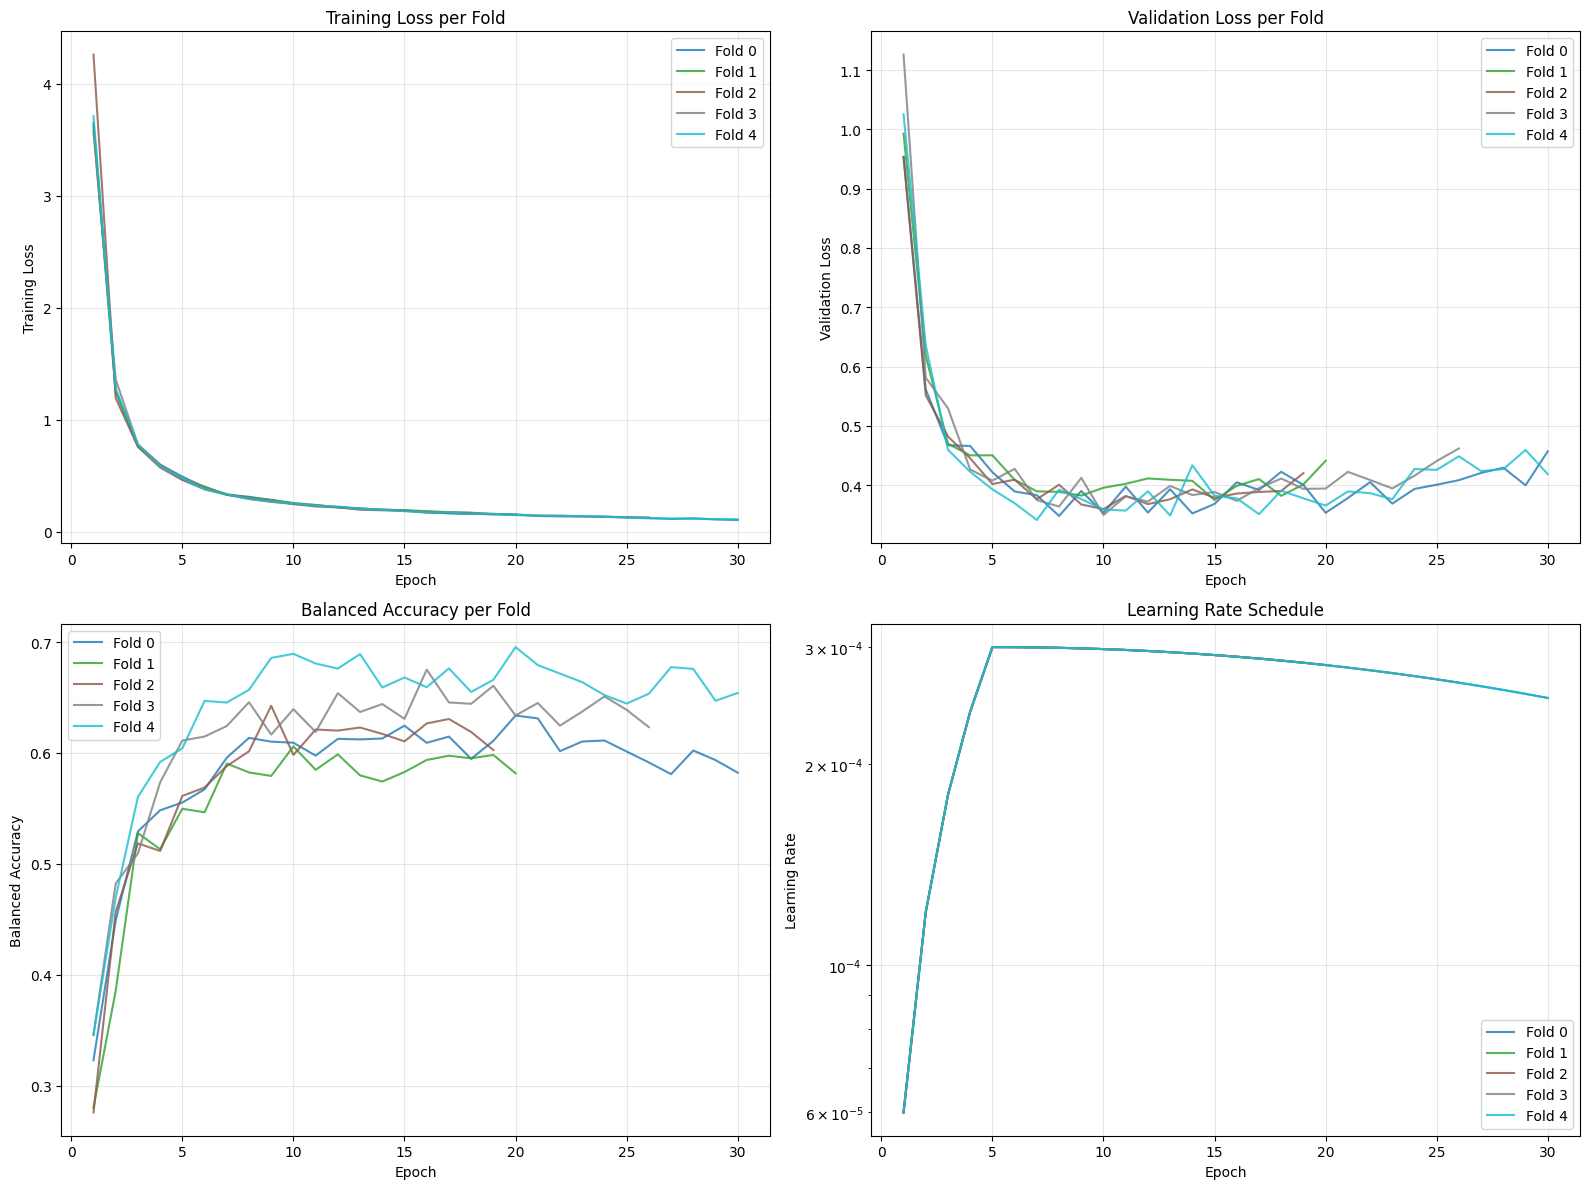

✓ Saved fold comparison plot to /kaggle/working/fold_comparison.png


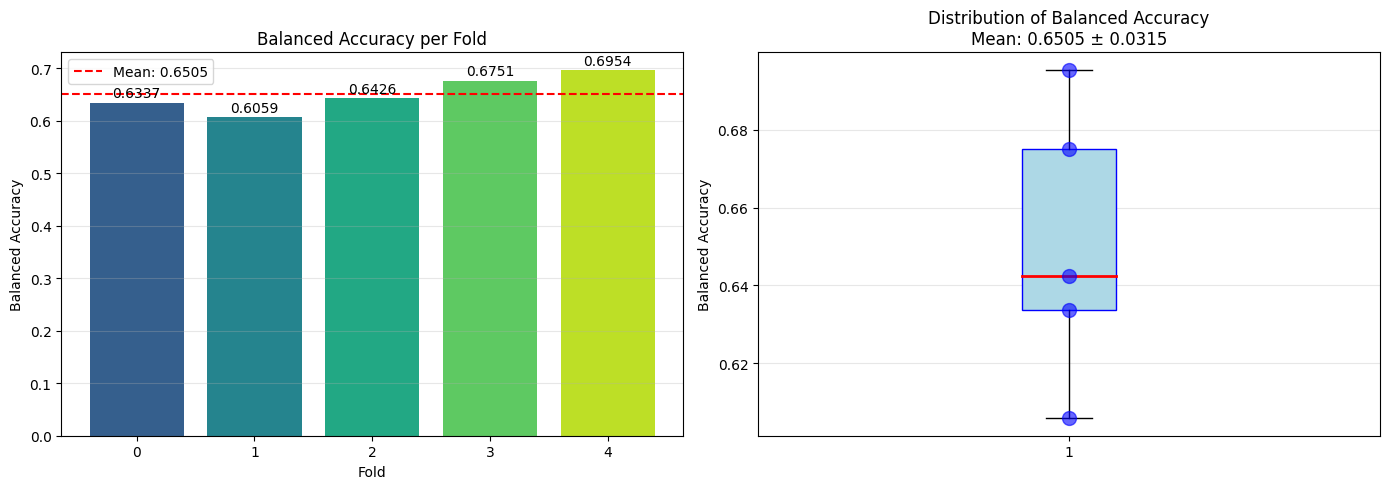

In [8]:
def plot_training_history(all_histories, cfg, save_path=None):
    """Vẽ biểu đồ training history cho tất cả folds"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = plt.cm.tab10(np.linspace(0, 1, cfg.N_FOLDS))
    
    # 1. Training Loss
    ax1 = axes[0, 0]
    for fold, history in enumerate(all_histories):
        ax1.plot(history['epoch'], history['train_loss'], 
                 label=f'Fold {fold}', color=colors[fold], alpha=0.8)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('Training Loss per Fold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Validation Loss
    ax2 = axes[0, 1]
    for fold, history in enumerate(all_histories):
        ax2.plot(history['epoch'], history['val_loss'], 
                 label=f'Fold {fold}', color=colors[fold], alpha=0.8)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Loss')
    ax2.set_title('Validation Loss per Fold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Balanced Accuracy
    ax3 = axes[1, 0]
    for fold, history in enumerate(all_histories):
        ax3.plot(history['epoch'], history['bal_acc'], 
                 label=f'Fold {fold}', color=colors[fold], alpha=0.8)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Balanced Accuracy')
    ax3.set_title('Balanced Accuracy per Fold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Learning Rate
    ax4 = axes[1, 1]
    for fold, history in enumerate(all_histories):
        ax4.plot(history['epoch'], history['learning_rate'], 
                 label=f'Fold {fold}', color=colors[fold], alpha=0.8)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Learning Rate')
    ax4.set_title('Learning Rate Schedule')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved training history plot to {save_path}")
    
    plt.show()


def plot_fold_comparison(results, cfg, save_path=None):
    """Vẽ biểu đồ so sánh performance giữa các folds"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Bar chart - Balanced Accuracy per fold
    ax1 = axes[0]
    folds = [r['fold'] for r in results]
    bal_accs = [r['best_bal_acc'] for r in results]
    bars = ax1.bar(folds, bal_accs, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(folds))))
    ax1.axhline(y=np.mean(bal_accs), color='red', linestyle='--', 
                label=f'Mean: {np.mean(bal_accs):.4f}')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('Balanced Accuracy')
    ax1.set_title('Balanced Accuracy per Fold')
    ax1.set_xticks(folds)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Thêm giá trị lên mỗi bar
    for bar, acc in zip(bars, bal_accs):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
    
    # 2. Box plot
    ax2 = axes[1]
    ax2.boxplot(bal_accs, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
    ax2.scatter([1]*len(bal_accs), bal_accs, color='blue', alpha=0.6, s=100, zorder=5)
    ax2.set_ylabel('Balanced Accuracy')
    ax2.set_title(f'Distribution of Balanced Accuracy\nMean: {np.mean(bal_accs):.4f} ± {np.std(bal_accs):.4f}')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved fold comparison plot to {save_path}")
    
    plt.show()


# Vẽ biểu đồ
plot_training_history(all_histories, cfg, save_path=os.path.join(cfg.OUTPUT_DIR, 'training_history.png'))
plot_fold_comparison(results, cfg, save_path=os.path.join(cfg.OUTPUT_DIR, 'fold_comparison.png'))

In [9]:
# Concat tất cả OOF predictions
oof_df = pd.concat(all_oof, ignore_index=True)
oof_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'oof_effnet_b0.csv'), index=False)

# Tính OOF balanced accuracy tổng
oof_preds_class = oof_df[[f'prob_{i}' for i in range(cfg.N_CLASSES)]].values.argmax(axis=1)
oof_bal_acc = balanced_accuracy_score(oof_df['target'], oof_preds_class)
print(f"\nOOF Balanced Accuracy: {oof_bal_acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    oof_df['target'], 
    oof_preds_class, 
    target_names=cfg.CLASS_NAMES
))

# ROC-AUC từng lớp (One-vs-Rest)
print("\nPer-class ROC-AUC:")
for i, class_name in enumerate(cfg.CLASS_NAMES):
    y_true_binary = (oof_df['target'] == i).astype(int)
    y_prob = oof_df[f'prob_{i}'].values
    try:
        auc_score = roc_auc_score(y_true_binary, y_prob)
        malignant = "⚠️ MALIGNANT" if class_name in ['MEL', 'BCC', 'SCC'] else ""
        print(f"  {class_name}: {auc_score:.4f} {malignant}")
    except:
        print(f"  {class_name}: N/A (only one class present)")

# Confusion matrix
cm = confusion_matrix(oof_df['target'], oof_preds_class)
print("\nConfusion Matrix:")
print(cm)


OOF Balanced Accuracy: 0.6531

Classification Report:
              precision    recall  f1-score   support

         MEL       0.54      0.64      0.59      4522
          NV       0.93      0.69      0.79     12875
         BCC       0.70      0.75      0.73      3323
          AK       0.31      0.50      0.39       867
         BKL       0.52      0.60      0.56      2624
          DF       0.29      0.71      0.41       239
        VASC       0.37      0.83      0.51       253
         SCC       0.23      0.51      0.32       628

    accuracy                           0.67     25331
   macro avg       0.49      0.65      0.54     25331
weighted avg       0.74      0.67      0.69     25331


Per-class ROC-AUC:
  MEL: 0.8628 ⚠️ MALIGNANT
  NV: 0.9312 
  BCC: 0.9579 ⚠️ MALIGNANT
  AK: 0.8929 
  BKL: 0.8818 
  DF: 0.9154 
  VASC: 0.9678 
  SCC: 0.8785 ⚠️ MALIGNANT

Confusion Matrix:
[[2890  519  183  213  384   60   48  225]
 [2001 8825  423  120  802  201  228  275]
 [ 100   29 248

In [10]:
# ==================== THRESHOLD OPTIMIZATION PER CLASS ====================
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_thresholds(oof_df, cfg, strategy='f1'):
    """
    Tìm optimal threshold cho từng class.
    
    Strategies:
    - 'f1': Maximize F1 score
    - 'recall': Đạt target recall (quan trọng cho malignant classes)
    - 'balanced': Cân bằng precision và recall
    
    Returns:
        optimal_thresholds: dict {class_name: threshold}
        threshold_metrics: dict với metrics tại optimal threshold
    """
    
    print(f"\n{'='*60}")
    print(f"THRESHOLD OPTIMIZATION (Strategy: {strategy})")
    print(f"{'='*60}")
    
    optimal_thresholds = {}
    threshold_metrics = {}
    
    # Lấy probabilities
    prob_cols = [f'prob_{i}' for i in range(cfg.N_CLASSES)]
    probs = oof_df[prob_cols].values
    targets = oof_df['target'].values
    
    for i, class_name in enumerate(cfg.CLASS_NAMES):
        y_true_binary = (targets == i).astype(int)
        y_prob = probs[:, i]
        
        # Tính precision, recall tại các thresholds
        precision, recall, thresholds = precision_recall_curve(y_true_binary, y_prob)
        
        # Loại bỏ threshold cuối (tương ứng với recall=0)
        precision = precision[:-1]
        recall = recall[:-1]
        
        if strategy == 'f1':
            # Maximize F1 score
            f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
            best_idx = np.argmax(f1_scores)
            best_threshold = thresholds[best_idx]
            best_f1 = f1_scores[best_idx]
            best_precision = precision[best_idx]
            best_recall = recall[best_idx]
            
        elif strategy == 'recall':
            # Đạt minimum recall (quan trọng cho malignant)
            target_recall = 0.85 if i in cfg.MALIGNANT_INDICES else 0.70
            # Tìm threshold thấp nhất đạt target recall
            valid_idx = np.where(recall >= target_recall)[0]
            if len(valid_idx) > 0:
                # Chọn threshold cao nhất trong các thresholds đạt target recall
                best_idx = valid_idx[np.argmax(precision[valid_idx])]
            else:
                # Fallback to maximum recall
                best_idx = np.argmax(recall)
            best_threshold = thresholds[best_idx]
            best_f1 = 2 * precision[best_idx] * recall[best_idx] / (precision[best_idx] + recall[best_idx] + 1e-8)
            best_precision = precision[best_idx]
            best_recall = recall[best_idx]
            
        else:  # 'balanced' or default
            # Minimize |precision - recall|
            diff = np.abs(precision - recall)
            best_idx = np.argmin(diff)
            best_threshold = thresholds[best_idx]
            best_f1 = 2 * precision[best_idx] * recall[best_idx] / (precision[best_idx] + recall[best_idx] + 1e-8)
            best_precision = precision[best_idx]
            best_recall = recall[best_idx]
        
        optimal_thresholds[class_name] = float(best_threshold)
        threshold_metrics[class_name] = {
            'threshold': float(best_threshold),
            'precision': float(best_precision),
            'recall': float(best_recall),
            'f1': float(best_f1),
            'support': int(y_true_binary.sum()),
            'is_malignant': i in cfg.MALIGNANT_INDICES
        }
        
        malignant_marker = "⚠️ MALIGNANT" if i in cfg.MALIGNANT_INDICES else ""
        print(f"  {class_name}: threshold={best_threshold:.4f}, P={best_precision:.3f}, R={best_recall:.3f}, F1={best_f1:.3f} {malignant_marker}")
    
    return optimal_thresholds, threshold_metrics


def apply_optimized_thresholds(probs, optimal_thresholds, class_names):
    """
    Áp dụng optimal thresholds để dự đoán.
    
    Logic: Với mỗi sample, chọn class có (prob / threshold) cao nhất
    """
    n_samples = probs.shape[0]
    n_classes = probs.shape[1]
    
    # Normalize probs by thresholds
    thresholds_array = np.array([optimal_thresholds[name] for name in class_names])
    normalized_probs = probs / (thresholds_array + 1e-8)
    
    # Chọn class có normalized prob cao nhất
    predictions = np.argmax(normalized_probs, axis=1)
    
    return predictions


def evaluate_with_optimized_thresholds(oof_df, optimal_thresholds, cfg):
    """Đánh giá performance với optimized thresholds"""
    
    prob_cols = [f'prob_{i}' for i in range(cfg.N_CLASSES)]
    probs = oof_df[prob_cols].values
    targets = oof_df['target'].values
    
    # Predictions với default threshold (argmax)
    default_preds = np.argmax(probs, axis=1)
    default_bal_acc = balanced_accuracy_score(targets, default_preds)
    
    # Predictions với optimized thresholds
    optimized_preds = apply_optimized_thresholds(probs, optimal_thresholds, cfg.CLASS_NAMES)
    optimized_bal_acc = balanced_accuracy_score(targets, optimized_preds)
    
    print(f"\n{'='*60}")
    print("COMPARISON: Default vs Optimized Thresholds")
    print(f"{'='*60}")
    print(f"Default (argmax) Balanced Accuracy: {default_bal_acc:.4f}")
    print(f"Optimized Thresholds Balanced Accuracy: {optimized_bal_acc:.4f}")
    print(f"Improvement: {(optimized_bal_acc - default_bal_acc)*100:+.2f}%")
    
    # Per-class comparison
    print(f"\nPer-class F1 comparison:")
    for i, class_name in enumerate(cfg.CLASS_NAMES):
        y_true = (targets == i).astype(int)
        
        # Default
        y_pred_default = (default_preds == i).astype(int)
        f1_default = f1_score(y_true, y_pred_default)
        
        # Optimized
        y_pred_opt = (optimized_preds == i).astype(int)
        f1_opt = f1_score(y_true, y_pred_opt)
        
        diff = f1_opt - f1_default
        marker = "⚠️" if i in cfg.MALIGNANT_INDICES else "  "
        arrow = "↑" if diff > 0 else "↓" if diff < 0 else "="
        print(f"  {marker} {class_name}: F1 {f1_default:.3f} -> {f1_opt:.3f} ({arrow}{abs(diff)*100:.1f}%)")
    
    return {
        'default_bal_acc': default_bal_acc,
        'optimized_bal_acc': optimized_bal_acc,
        'default_preds': default_preds,
        'optimized_preds': optimized_preds
    }


# ========== CHẠY THRESHOLD OPTIMIZATION ==========
print("\n" + "="*60)
print("STEP: THRESHOLD OPTIMIZATION")
print("="*60)

# Strategy 1: F1 optimization
optimal_thresholds_f1, metrics_f1 = find_optimal_thresholds(oof_df, cfg, strategy='f1')

# Strategy 2: Recall optimization (ưu tiên malignant)
optimal_thresholds_recall, metrics_recall = find_optimal_thresholds(oof_df, cfg, strategy='recall')

# Evaluate với F1 optimized thresholds
print("\n>>> Evaluating with F1-optimized thresholds:")
eval_results_f1 = evaluate_with_optimized_thresholds(oof_df, optimal_thresholds_f1, cfg)

# Evaluate với Recall optimized thresholds  
print("\n>>> Evaluating with Recall-optimized thresholds:")
eval_results_recall = evaluate_with_optimized_thresholds(oof_df, optimal_thresholds_recall, cfg)

# Lưu optimal thresholds
thresholds_output = {
    'f1_strategy': {
        'thresholds': optimal_thresholds_f1,
        'metrics': metrics_f1,
        'balanced_accuracy': eval_results_f1['optimized_bal_acc']
    },
    'recall_strategy': {
        'thresholds': optimal_thresholds_recall,
        'metrics': metrics_recall,
        'balanced_accuracy': eval_results_recall['optimized_bal_acc']
    }
}

thresholds_path = os.path.join(cfg.OUTPUT_DIR, 'optimal_thresholds.json')
with open(thresholds_path, 'w') as f:
    json.dump(thresholds_output, f, indent=4)
print(f"\n✓ Saved optimal thresholds to {thresholds_path}")



STEP: THRESHOLD OPTIMIZATION

THRESHOLD OPTIMIZATION (Strategy: f1)
  MEL: threshold=0.4109, P=0.571, R=0.606, F1=0.588 ⚠️ MALIGNANT
  NV: threshold=0.0587, P=0.828, R=0.902, F1=0.864 
  BCC: threshold=0.3513, P=0.715, R=0.761, F1=0.738 ⚠️ MALIGNANT
  AK: threshold=0.4602, P=0.353, R=0.451, F1=0.396 
  BKL: threshold=0.3899, P=0.558, R=0.589, F1=0.573 
  DF: threshold=0.7905, P=0.588, R=0.490, F1=0.534 
  VASC: threshold=0.8960, P=0.743, R=0.652, F1=0.695 
  SCC: threshold=0.5713, P=0.348, R=0.436, F1=0.387 ⚠️ MALIGNANT

THRESHOLD OPTIMIZATION (Strategy: recall)
  MEL: threshold=0.1287, P=0.379, R=0.850, F1=0.524 ⚠️ MALIGNANT
  NV: threshold=0.3459, P=0.925, R=0.700, F1=0.797 
  BCC: threshold=0.1820, P=0.624, R=0.850, F1=0.720 ⚠️ MALIGNANT
  AK: threshold=0.1148, P=0.209, R=0.700, F1=0.322 
  BKL: threshold=0.2258, P=0.436, R=0.700, F1=0.538 
  DF: threshold=0.3967, P=0.346, R=0.703, F1=0.463 
  VASC: threshold=0.7437, P=0.624, R=0.708, F1=0.663 
  SCC: threshold=0.0487, P=0.077, R=0

✓ Saved confusion matrix plot to /kaggle/working/confusion_matrix.png


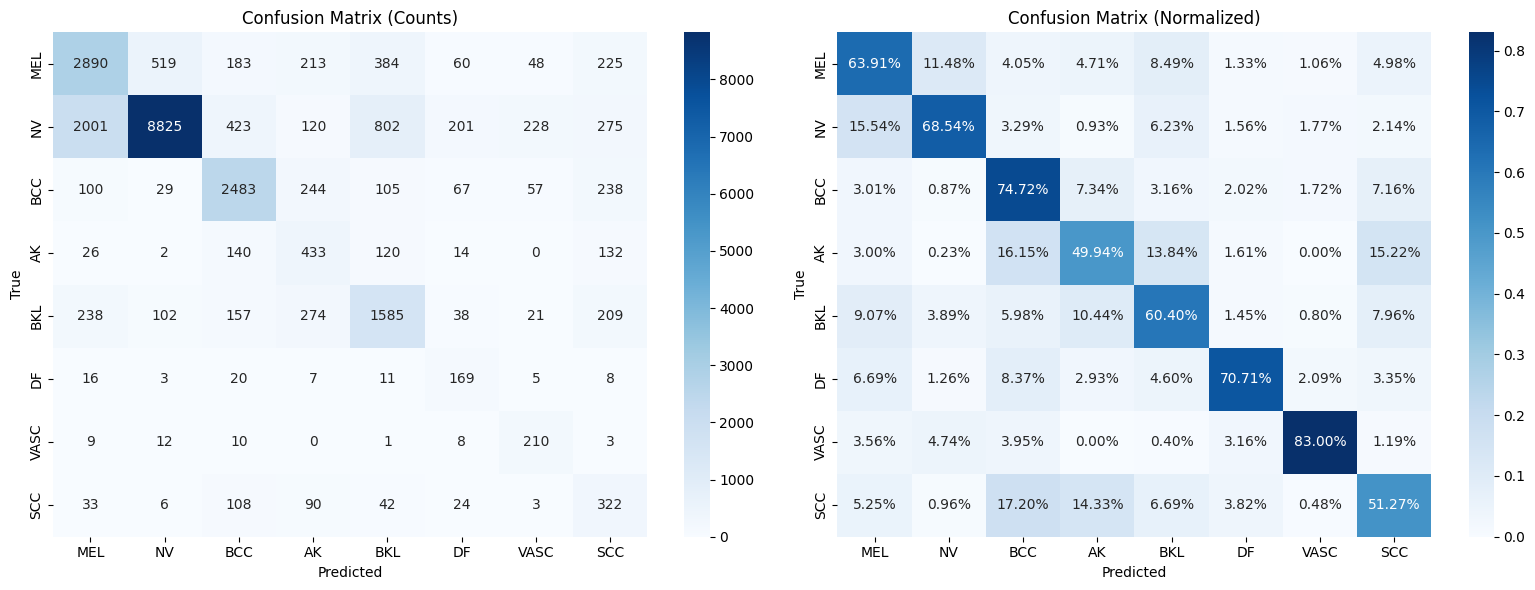

✓ Saved ROC curves plot to /kaggle/working/roc_curves.png


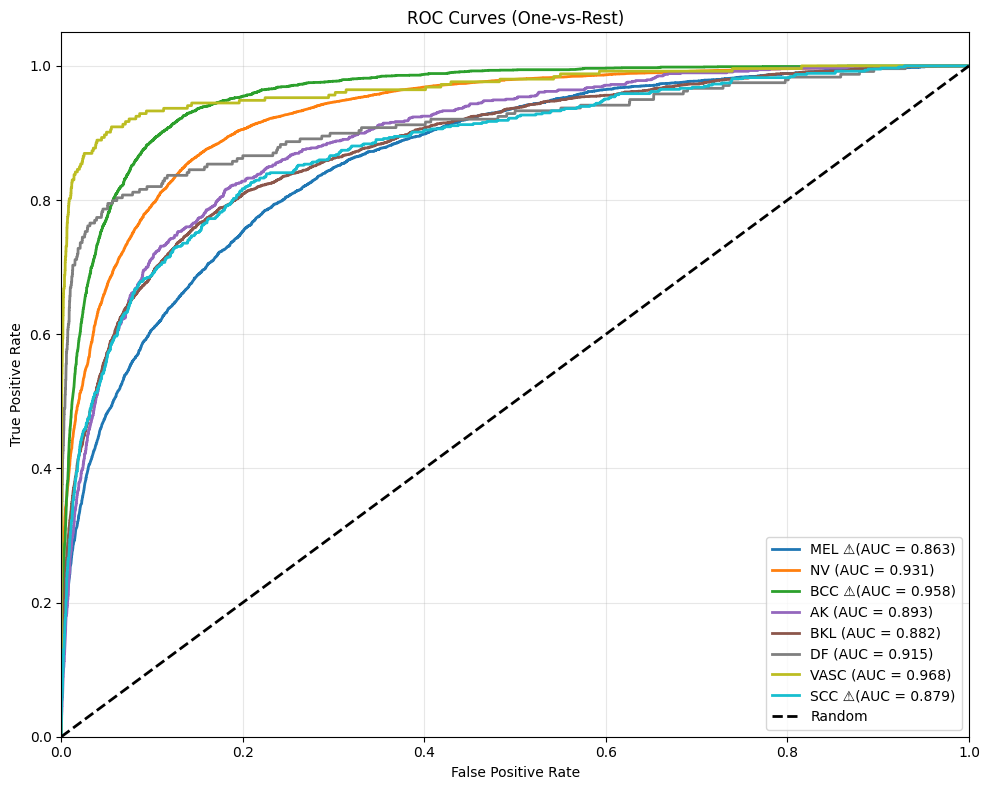

✓ Saved class distribution plot to /kaggle/working/class_distribution.png


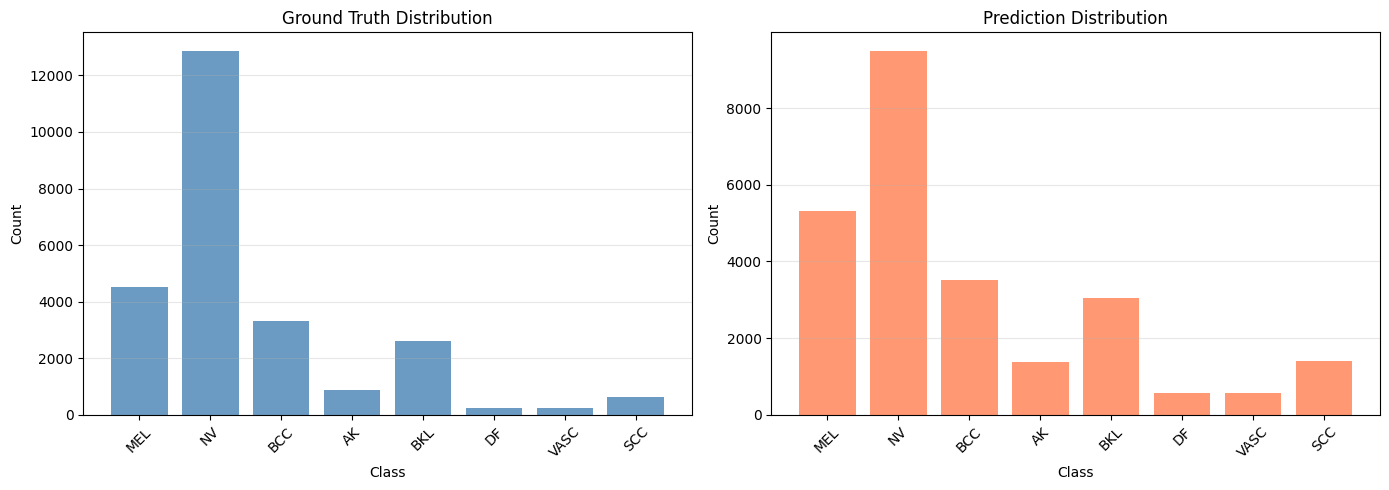

In [11]:
def plot_confusion_matrix(cm, class_names, save_path=None):
    """Vẽ confusion matrix với heatmap"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Confusion matrix (counts)
    ax1 = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    ax1.set_title('Confusion Matrix (Counts)')
    
    # 2. Confusion matrix (normalized)
    ax2 = axes[1]
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix (Normalized)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved confusion matrix plot to {save_path}")
    
    plt.show()


def plot_roc_curves(oof_df, cfg, save_path=None):
    """Vẽ ROC curves cho từng class"""
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, cfg.N_CLASSES))
    
    for i, class_name in enumerate(cfg.CLASS_NAMES):
        y_true_binary = (oof_df['target'] == i).astype(int)
        y_prob = oof_df[f'prob_{i}'].values
        
        if y_true_binary.sum() > 0:
            fpr, tpr, _ = roc_curve(y_true_binary, y_prob)
            roc_auc = auc(fpr, tpr)
            
            marker = '⚠️' if class_name in ['MEL', 'BCC', 'SCC'] else ''
            ax.plot(fpr, tpr, color=colors[i], lw=2,
                    label=f'{class_name} {marker}(AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves (One-vs-Rest)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved ROC curves plot to {save_path}")
    
    plt.show()


def plot_class_distribution(oof_df, cfg, save_path=None):
    """Vẽ phân phối class trong predictions vs ground truth"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    pred_classes = oof_df[[f'prob_{i}' for i in range(cfg.N_CLASSES)]].values.argmax(axis=1)
    
    # 1. Ground truth distribution
    ax1 = axes[0]
    true_counts = oof_df['target'].value_counts().sort_index()
    ax1.bar(cfg.CLASS_NAMES, true_counts.values, color='steelblue', alpha=0.8)
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Count')
    ax1.set_title('Ground Truth Distribution')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Prediction distribution
    ax2 = axes[1]
    pred_counts = pd.Series(pred_classes).value_counts().sort_index()
    pred_counts_full = [pred_counts.get(i, 0) for i in range(cfg.N_CLASSES)]
    ax2.bar(cfg.CLASS_NAMES, pred_counts_full, color='coral', alpha=0.8)
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Count')
    ax2.set_title('Prediction Distribution')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved class distribution plot to {save_path}")
    
    plt.show()


# Vẽ các biểu đồ
plot_confusion_matrix(cm, cfg.CLASS_NAMES, save_path=os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'))
plot_roc_curves(oof_df, cfg, save_path=os.path.join(cfg.OUTPUT_DIR, 'roc_curves.png'))
plot_class_distribution(oof_df, cfg, save_path=os.path.join(cfg.OUTPUT_DIR, 'class_distribution.png'))

In [12]:
def tta_predict(model, image, val_transforms, device):
    """Test Time Augmentation với flip"""
    model.eval()
    preds = []
    
    with torch.no_grad():
        # Original
        img = val_transforms(image=image)["image"].unsqueeze(0).to(device)
        with autocast():
            preds.append(torch.softmax(model(img), dim=1))
        
        # Horizontal flip
        img_hflip = val_transforms(image=cv2.flip(image, 1))["image"].unsqueeze(0).to(device)
        with autocast():
            preds.append(torch.softmax(model(img_hflip), dim=1))
        
        # Vertical flip
        img_vflip = val_transforms(image=cv2.flip(image, 0))["image"].unsqueeze(0).to(device)
        with autocast():
            preds.append(torch.softmax(model(img_vflip), dim=1))
    
    return torch.stack(preds).mean(dim=0)


def inference_test(test_csv_path, test_img_root, cfg, use_tta=True):
    """Inference với ensemble 5 folds + optional TTA"""
    test_df = pd.read_csv(test_csv_path)
    val_transforms = get_val_transforms(cfg.IMG_SIZE)
    
    print(f"\n{'='*50}")
    print(f"TEST SET INFERENCE")
    print(f"{'='*50}")
    print(f"Test samples: {len(test_df)}")
    print(f"Test images folder: {test_img_root}")
    print(f"Using TTA: {use_tta}")
    
    # Load 5 models
    models = []
    for fold in range(cfg.N_FOLDS):
        model = create_model(cfg, use_dp=True)
        
        checkpoint_path = os.path.join(cfg.OUTPUT_DIR, f"effnet_b0_fold{fold}_best.pth")
        checkpoint = torch.load(checkpoint_path, map_location=cfg.DEVICE, weights_only=False)
        
        # Handle DataParallel state_dict
        state_dict = checkpoint['model_state_dict']
        if isinstance(model, nn.DataParallel):
            if not any(k.startswith('module.') for k in state_dict.keys()):
                state_dict = {f'module.{k}': v for k, v in state_dict.items()}
        else:
            if any(k.startswith('module.') for k in state_dict.keys()):
                state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
        model.load_state_dict(state_dict)
        model.eval()
        models.append(model)
        print(f"  ✓ Loaded fold {fold} (best_bal_acc: {checkpoint['best_bal_acc']:.4f})")
    
    print(f"Loaded {len(models)} fold models")
    
    # Predict
    all_preds = []
    all_images = []
    
    for idx in tqdm(range(len(test_df)), desc="Inference on Test Set"):
        row = test_df.iloc[idx]
        
        img_path = os.path.join(test_img_root, os.path.basename(row["path"]))
        image = cv2.imread(img_path)
        
        if image is None:
            print(f"Warning: Cannot read image {img_path}")
            continue
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        all_images.append(row['image'])
        
        # Ensemble predictions từ 5 folds
        fold_preds = []
        for model in models:
            if use_tta:
                pred = tta_predict(model, image, val_transforms, cfg.DEVICE)
            else:
                img_tensor = val_transforms(image=image)["image"].unsqueeze(0).to(cfg.DEVICE)
                with torch.no_grad(), autocast():
                    pred = torch.softmax(model(img_tensor), dim=1)
            fold_preds.append(pred)
        
        # Average across folds
        avg_pred = torch.stack(fold_preds).mean(dim=0).cpu().numpy()[0]
        all_preds.append(avg_pred)
    
    all_preds = np.array(all_preds)
    pred_classes = all_preds.argmax(axis=1)
    
    # Tạo submission DataFrame
    submission = pd.DataFrame({
        'image': all_images,
        **{f'prob_{i}': all_preds[:, i] for i in range(cfg.N_CLASSES)},
        'pred': pred_classes,
        'pred_label': [cfg.CLASS_NAMES[p] for p in pred_classes]
    })
    
    # Lưu predictions
    output_path = os.path.join(cfg.OUTPUT_DIR, 'effnet_b0_test_predictions.csv')
    submission.to_csv(output_path, index=False)
    print(f"\n✓ Saved test predictions to {output_path}")
    
    # Thống kê predictions
    print(f"\nTest Set Prediction Distribution:")
    for i, class_name in enumerate(cfg.CLASS_NAMES):
        count = (pred_classes == i).sum()
        pct = count / len(pred_classes) * 100
        print(f"  {class_name}: {count} ({pct:.1f}%)")
    
    # Cleanup
    for model in models:
        del model
    torch.cuda.empty_cache()
    
    return submission

In [13]:
# ====== CHẠY INFERENCE TRÊN TEST SET ======
print("\n" + "="*60)
print("STEP: INFERENCE ON TEST SET")
print("="*60)

# Chạy inference với TTA
test_submission = inference_test(
    test_csv_path=cfg.TEST_CSV_PATH,
    test_img_root=cfg.TEST_IMG_ROOT,
    cfg=cfg,
    use_tta=True
)

print("\n" + "="*60)
print("TRAINING & INFERENCE COMPLETED!")
print("="*60)
print(f"\nOutput files:")
print(f"  - OOF predictions: {cfg.OUTPUT_DIR}/oof_effnet_b0.csv")
print(f"  - Test predictions: {cfg.OUTPUT_DIR}/effnet_b0_test_predictions.csv")
print(f"  - Model checkpoints: {cfg.OUTPUT_DIR}/effnet_b0_fold*_best.pth")


STEP: INFERENCE ON TEST SET

TEST SET INFERENCE
Test samples: 6191
Test images folder: /kaggle/input/isic-2019-task-1/cropped_lesions_testset/cropped_lesions_testset
Using TTA: True
Using DataParallel with 2 GPUs
  ✓ Loaded fold 0 (best_bal_acc: 0.6337)
Using DataParallel with 2 GPUs
  ✓ Loaded fold 1 (best_bal_acc: 0.6059)
Using DataParallel with 2 GPUs
  ✓ Loaded fold 2 (best_bal_acc: 0.6426)
Using DataParallel with 2 GPUs
  ✓ Loaded fold 3 (best_bal_acc: 0.6751)
Using DataParallel with 2 GPUs
  ✓ Loaded fold 4 (best_bal_acc: 0.6954)
Loaded 5 fold models


Inference on Test Set: 100%|██████████| 6191/6191 [43:39<00:00,  2.36it/s]


✓ Saved test predictions to /kaggle/working/effnet_b0_test_predictions.csv

Test Set Prediction Distribution:
  MEL: 1399 (22.6%)
  NV: 1831 (29.6%)
  BCC: 1120 (18.1%)
  AK: 485 (7.8%)
  BKL: 763 (12.3%)
  DF: 137 (2.2%)
  VASC: 131 (2.1%)
  SCC: 325 (5.2%)

TRAINING & INFERENCE COMPLETED!

Output files:
  - OOF predictions: /kaggle/working/oof_effnet_b0.csv
  - Test predictions: /kaggle/working/effnet_b0_test_predictions.csv
  - Model checkpoints: /kaggle/working/effnet_b0_fold*_best.pth


In [14]:
def save_experiment_results(cfg, results, all_histories, oof_df, test_submission, save_dir):
    """Lưu toàn bộ config, kết quả training/val và test"""
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. Lưu Config (bao gồm các cải tiến mới)
    config_dict = {
        'experiment_timestamp': timestamp,
        'model_name': cfg.MODEL_NAME,
        'n_classes': cfg.N_CLASSES,
        'img_size': cfg.IMG_SIZE,
        'n_folds': cfg.N_FOLDS,
        'batch_size': cfg.BATCH_SIZE,
        'epochs': cfg.EPOCHS,
        'min_epochs': cfg.MIN_EPOCHS,
        'patience': cfg.PATIENCE,
        'base_lr': cfg.BASE_LR,
        'min_lr': cfg.MIN_LR,
        'weight_decay': cfg.WEIGHT_DECAY,
        'warmup_epochs': cfg.WARMUP_EPOCHS,
        'drop_rate': cfg.DROP_RATE,
        'pretrained': cfg.PRETRAINED,
        'label_smoothing': cfg.LABEL_SMOOTHING,
        # ===== MỚI: Focal Loss & Class-balanced Sampling =====
        'use_focal_loss': cfg.USE_FOCAL_LOSS,
        'focal_gamma': cfg.FOCAL_GAMMA,
        'focal_alpha': cfg.FOCAL_ALPHA,
        'use_class_balanced_sampling': cfg.USE_CLASS_BALANCED_SAMPLING,
        'malignant_boost': cfg.MALIGNANT_BOOST,
        'scc_extra_boost': cfg.SCC_EXTRA_BOOST,
        'malignant_indices': list(cfg.MALIGNANT_INDICES),
        # =====================================================
        'class_names': list(cfg.CLASS_NAMES),
        'paths': {
            'csv_path': cfg.CSV_PATH,
            'img_root': cfg.IMG_ROOT,
            'test_csv_path': cfg.TEST_CSV_PATH,
            'test_img_root': cfg.TEST_IMG_ROOT,
            'output_dir': cfg.OUTPUT_DIR,
        }
    }
    
    config_path = os.path.join(save_dir, 'experiment_config.json')
    with open(config_path, 'w') as f:
        json.dump(config_dict, f, indent=4)
    print(f"✓ Saved config to {config_path}")
    
    # 2. Lưu Training Results
    training_results = {
        'timestamp': timestamp,
        'fold_results': [],
        'summary': {
            'mean_bal_acc': float(np.mean([r['best_bal_acc'] for r in results])),
            'std_bal_acc': float(np.std([r['best_bal_acc'] for r in results])),
            'best_fold': int(np.argmax([r['best_bal_acc'] for r in results])),
            'best_bal_acc': float(max([r['best_bal_acc'] for r in results])),
        }
    }
    
    for r in results:
        training_results['fold_results'].append({
            'fold': r['fold'],
            'best_bal_acc': float(r['best_bal_acc']),
            'checkpoint_path': r['checkpoint_path'],
            'n_epochs_trained': len(r['history']['epoch']),
        })
    
    results_path = os.path.join(save_dir, 'training_results.json')
    with open(results_path, 'w') as f:
        json.dump(training_results, f, indent=4)
    print(f"✓ Saved training results to {results_path}")
    
    # 3. Lưu Training History
    all_history_dfs = []
    for fold, history in enumerate(all_histories):
        history_df = pd.DataFrame(history)
        history_df['fold'] = fold
        all_history_dfs.append(history_df)
    
    combined_history = pd.concat(all_history_dfs, ignore_index=True)
    history_path = os.path.join(save_dir, 'training_history.csv')
    combined_history.to_csv(history_path, index=False)
    print(f"✓ Saved training history to {history_path}")
    
    # 4. Lưu OOF Metrics
    oof_preds_class = oof_df[[f'prob_{i}' for i in range(cfg.N_CLASSES)]].values.argmax(axis=1)
    
    oof_metrics = {
        'timestamp': timestamp,
        'overall': {
            'balanced_accuracy': float(balanced_accuracy_score(oof_df['target'], oof_preds_class)),
            'total_samples': len(oof_df),
        },
        'per_class': {}
    }
    
    for i, class_name in enumerate(cfg.CLASS_NAMES):
        y_true_binary = (oof_df['target'] == i).astype(int)
        y_prob = oof_df[f'prob_{i}'].values
        y_pred_binary = (oof_preds_class == i).astype(int)
        
        tp = ((y_true_binary == 1) & (y_pred_binary == 1)).sum()
        fp = ((y_true_binary == 0) & (y_pred_binary == 1)).sum()
        fn = ((y_true_binary == 1) & (y_pred_binary == 0)).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        try:
            auc_score = float(roc_auc_score(y_true_binary, y_prob))
        except:
            auc_score = None
        
        oof_metrics['per_class'][class_name] = {
            'support': int(y_true_binary.sum()),
            'precision': float(precision),
            'recall': float(recall),
            'f1_score': float(f1),
            'roc_auc': auc_score,
            'is_malignant': class_name in ['MEL', 'BCC', 'SCC'],
        }
    
    oof_metrics_path = os.path.join(save_dir, 'oof_metrics.json')
    with open(oof_metrics_path, 'w') as f:
        json.dump(oof_metrics, f, indent=4)
    print(f"✓ Saved OOF metrics to {oof_metrics_path}")
    
    # 5. Lưu Test Results
    if test_submission is not None:
        test_results = {
            'timestamp': timestamp,
            'total_samples': len(test_submission),
            'prediction_distribution': {}
        }
        
        pred_classes = test_submission['pred'].values
        for i, class_name in enumerate(cfg.CLASS_NAMES):
            count = int((pred_classes == i).sum())
            pct = count / len(pred_classes) * 100
            test_results['prediction_distribution'][class_name] = {
                'count': count,
                'percentage': round(pct, 2)
            }
        
        test_results_path = os.path.join(save_dir, 'test_results.json')
        with open(test_results_path, 'w') as f:
            json.dump(test_results, f, indent=4)
        print(f"✓ Saved test results to {test_results_path}")
    
    # 6. Summary Report
    summary_report = f"""
{'='*60}
EXPERIMENT SUMMARY REPORT
{'='*60}
Timestamp: {timestamp}
Model: {cfg.MODEL_NAME}

CONFIGURATION:
- Image Size: {cfg.IMG_SIZE}
- Batch Size: {cfg.BATCH_SIZE}
- Learning Rate: {cfg.BASE_LR}
- Weight Decay: {cfg.WEIGHT_DECAY}
- Epochs: {cfg.EPOCHS} (min: {cfg.MIN_EPOCHS}, patience: {cfg.PATIENCE})
- Dropout Rate: {cfg.DROP_RATE}
- Warmup Epochs: {cfg.WARMUP_EPOCHS}

TRAINING RESULTS (5-Fold CV):
- Mean Balanced Accuracy: {training_results['summary']['mean_bal_acc']:.4f} ± {training_results['summary']['std_bal_acc']:.4f}
- Best Fold: {training_results['summary']['best_fold']} ({training_results['summary']['best_bal_acc']:.4f})

OOF RESULTS:
- Overall Balanced Accuracy: {oof_metrics['overall']['balanced_accuracy']:.4f}

Per-class Performance:
"""
    
    class_aucs = [(name, metrics['roc_auc'], metrics['is_malignant']) 
                  for name, metrics in oof_metrics['per_class'].items() 
                  if metrics['roc_auc'] is not None]
    class_aucs.sort(key=lambda x: x[1], reverse=True)
    
    for class_name, auc_val, is_malignant in class_aucs:
        marker = "⚠️ MALIGNANT" if is_malignant else ""
        metrics = oof_metrics['per_class'][class_name]
        summary_report += f"  {class_name}: AUC={auc_val:.4f}, F1={metrics['f1_score']:.4f}, Support={metrics['support']} {marker}\n"
    
    if test_submission is not None:
        summary_report += f"""
TEST SET PREDICTIONS:
- Total Samples: {test_results['total_samples']}
"""
    
    summary_report += f"""
{'='*60}
"""
    
    report_path = os.path.join(save_dir, 'experiment_summary.txt')
    with open(report_path, 'w') as f:
        f.write(summary_report)
    print(f"✓ Saved experiment summary to {report_path}")
    
    print(summary_report)


# Lưu toàn bộ kết quả
save_experiment_results(
    cfg=cfg,
    results=results,
    all_histories=all_histories,
    oof_df=oof_df,
    test_submission=test_submission,
    save_dir=cfg.OUTPUT_DIR
)

print("\n" + "="*60)
print("🎉 ALL RESULTS SAVED SUCCESSFULLY!")
print("="*60)

✓ Saved config to /kaggle/working/experiment_config.json
✓ Saved training results to /kaggle/working/training_results.json
✓ Saved training history to /kaggle/working/training_history.csv
✓ Saved OOF metrics to /kaggle/working/oof_metrics.json
✓ Saved test results to /kaggle/working/test_results.json
✓ Saved experiment summary to /kaggle/working/experiment_summary.txt

EXPERIMENT SUMMARY REPORT
Timestamp: 20251126_004704
Model: efficientnet_b0

CONFIGURATION:
- Image Size: 256
- Batch Size: 64
- Learning Rate: 0.0003
- Weight Decay: 0.0005
- Epochs: 100 (min: 15, patience: 10)
- Dropout Rate: 0.4
- Warmup Epochs: 5

TRAINING RESULTS (5-Fold CV):
- Mean Balanced Accuracy: 0.6505 ± 0.0315
- Best Fold: 4 (0.6954)

OOF RESULTS:
- Overall Balanced Accuracy: 0.6531

Per-class Performance:
  VASC: AUC=0.9678, F1=0.5091, Support=253 
  BCC: AUC=0.9579, F1=0.7253, Support=3323 ⚠️ MALIGNANT
  NV: AUC=0.9312, F1=0.7889, Support=12875 
  DF: AUC=0.9154, F1=0.4122, Support=239 
  AK: AUC=0.8929, F1

In [15]:
# Liệt kê tất cả output files
print("="*60)
print("OUTPUT FILES")
print("="*60)

import glob

output_files = glob.glob(os.path.join(cfg.OUTPUT_DIR, '*'))
for f in sorted(output_files):
    size = os.path.getsize(f)
    if size > 1024*1024:
        size_str = f"{size/1024/1024:.2f} MB"
    elif size > 1024:
        size_str = f"{size/1024:.2f} KB"
    else:
        size_str = f"{size} B"
    print(f"  {os.path.basename(f):40} {size_str}")

print("="*60)

OUTPUT FILES
  __notebook__.ipynb                       19.21 MB
  class_distribution.png                   51.31 KB
  confusion_matrix.png                     220.17 KB
  effnet_b0_fold0_best.pth                 46.44 MB
  effnet_b0_fold1_best.pth                 46.44 MB
  effnet_b0_fold2_best.pth                 46.44 MB
  effnet_b0_fold3_best.pth                 46.44 MB
  effnet_b0_fold4_best.pth                 46.44 MB
  effnet_b0_test_predictions.csv           681.07 KB
  experiment_config.json                   1.18 KB
  experiment_summary.txt                   1.02 KB
  fold_comparison.png                      68.25 KB
  oof_effnet_b0.csv                        1.99 MB
  oof_metrics.json                         2.23 KB
  optimal_thresholds.json                  5.34 KB
  roc_curves.png                           176.74 KB
  test_results.json                        788 B
  training_history.csv                     10.33 KB
  training_history.png                     303.68 KB
  t